In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sys
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Add src folder to path for custom modules
sys.path.append('../src')
from evaluation import evaluate_model, plot_confusion_matrix, plot_roc_curve, compare_models
from utils import (
    load_processed_data,
    get_features_and_target,
    print_dataset_info,
    plot_class_distribution
 )

print("Libraries and custom helpers loaded successfully!")

Libraries and custom helpers loaded successfully!


In [22]:
# Load preprocessed data using utils.py
datasets = load_processed_data()

X_train, y_train = get_features_and_target(datasets['train'])
X_test, y_test = get_features_and_target(datasets['test'])

print_dataset_info(datasets['train'], 'Training Set (SMOTE)')
print_dataset_info(datasets['test'], 'Test Set')

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Training Set (SMOTE) Information
Shape: (14188, 23)
Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'Default']

Target distribution:
Default
1    7094
0    7094
Name: count, dtype: int64

Test Set Information
Shape: (2000, 23)
Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', '

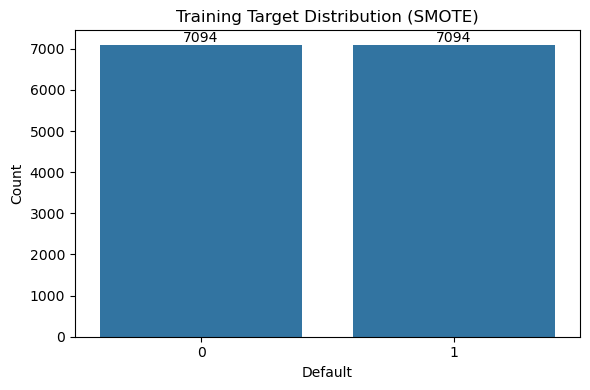

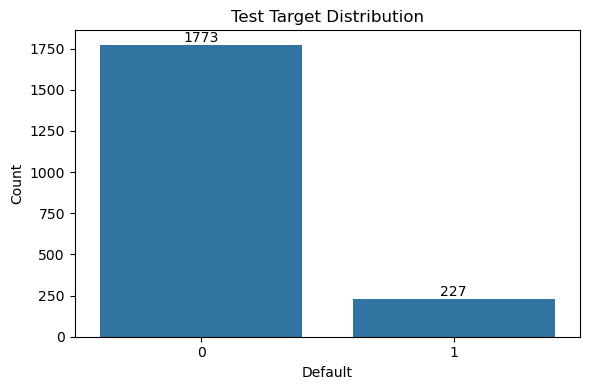

X_train shape: (14188, 22)
y_train shape: (14188,)
X_test shape: (2000, 22)
y_test shape: (2000,)


In [23]:
# Quick class-distribution check (same style as Random Forest workflow)
plot_class_distribution(y_train, 'Training Target Distribution (SMOTE)')
plot_class_distribution(y_test, 'Test Target Distribution')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

In [24]:
#Check feature names
feature_names = X_train.columns.tolist()
print(feature_names)

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other']


In [25]:
# Baseline model + stronger regularized hyperparameter search setup
dt_baseline = DecisionTreeClassifier(random_state=42, class_weight=None)

param_distributions = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 5, 7, 10, 12, 15],
    'min_samples_split': [10, 20, 40, 60, 100],
    'min_samples_leaf': [5, 10, 20, 30, 50],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.7],
    'ccp_alpha': [0.0, 0.0005, 0.001, 0.005, 0.01]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

In [26]:
# Train baseline and tuned models
dt_baseline.fit(X_train, y_train)
y_test_pred_baseline = dt_baseline.predict(X_test)
y_test_pred_proba_baseline = dt_baseline.predict_proba(X_test)[:, 1]

print("Baseline Decision Tree trained successfully!")
print("Starting RandomizedSearchCV for Decision Tree...")
dt_search.fit(X_train, y_train)
dt_model = dt_search.best_estimator_
print(f"Best parameters: {dt_search.best_params_}")
print(f"Best CV F1 score: {dt_search.best_score_:.4f}")

Baseline Decision Tree trained successfully!
Starting RandomizedSearchCV for Decision Tree...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'log_loss', 'ccp_alpha': 0.0005}
Best CV F1 score: 0.7914


In [27]:
# Make tuned-model predictions + threshold optimization
y_train_pred = dt_model.predict(X_train)
y_test_pred_proba = dt_model.predict_proba(X_test)[:, 1]

# Tune threshold on a practical range for imbalanced classification
thresholds = np.arange(0.05, 0.51, 0.01)
optimize_metric = 'f1'  # change to 'recall' if missing defaulters is most costly
threshold_results = []

for threshold in thresholds:
    y_pred_temp = (y_test_pred_proba >= threshold).astype(int)
    threshold_results.append({
        'threshold': threshold,
        'f1': f1_score(y_test, y_pred_temp, zero_division=0),
        'precision': precision_score(y_test, y_pred_temp, zero_division=0),
        'recall': recall_score(y_test, y_pred_temp, zero_division=0),
        'accuracy': accuracy_score(y_test, y_pred_temp)
    })

threshold_df = pd.DataFrame(threshold_results)
best_idx = threshold_df[optimize_metric].idxmax()
best_threshold = threshold_df.loc[best_idx, 'threshold']
y_test_pred = (y_test_pred_proba >= best_threshold).astype(int)

print(f"Best threshold based on {optimize_metric.upper()}: {best_threshold:.2f}")

Best threshold based on F1: 0.49


In [28]:
#Calculate training results
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, zero_division=0)
train_recall = recall_score(y_train, y_train_pred, zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, zero_division=0)

print("Training Accuracy:", train_accuracy)
print("Training Precision:", train_precision)
print("Training Recall:", train_recall)
print("Training F1-score:", train_f1)


Training Accuracy: 0.8350718917394981
Training Precision: 0.8384111617312073
Training Recall: 0.8301381449111925
Training F1-score: 0.8342541436464088


In [29]:
#Calculate test results
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1-score:", test_f1)
print("Test ROC-AUC:", test_roc_auc)


Test Accuracy: 0.734
Test Precision: 0.19560878243512975
Test Recall: 0.43171806167400884
Test F1-score: 0.2692307692307692
Test ROC-AUC: 0.640259795115673


In [30]:
# Compare baseline vs tuned Decision Tree
baseline_metrics = evaluate_model(
    y_test,
    y_test_pred_baseline,
    y_test_pred_proba_baseline,
    'Decision Tree (Baseline)'
)

tuned_metrics = evaluate_model(
    y_test,
    y_test_pred,
    y_test_pred_proba,
    f'Decision Tree (Tuned, threshold={best_threshold:.2f})'
)

# Focus on the five metrics you want to explain
metric_order = ['accuracy', 'precision', 'recall', 'f1_score', 'auc_roc']
metric_labels = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1_score': 'F1-score',
    'auc_roc': 'ROC-AUC'
}

comparison_summary = pd.DataFrame({
    'Metric': [metric_labels[m] for m in metric_order],
    'Baseline Decision Tree': [baseline_metrics[m] for m in metric_order],
    'Tuned Decision Tree': [tuned_metrics[m] for m in metric_order]
})
comparison_summary['Improvement (Tuned - Baseline)'] = (
    comparison_summary['Tuned Decision Tree'] - comparison_summary['Baseline Decision Tree']
)

comparison_summary = comparison_summary.round(4)
print('Baseline vs Tuned Decision Tree (Test Metrics)')
comparison_summary


Decision Tree (Baseline) Evaluation Results
ACCURACY    : 0.7680
PRECISION   : 0.1605
RECALL      : 0.2467
F1_SCORE    : 0.1944
AUC_ROC     : 0.5407

Classification Report:
              precision    recall  f1-score   support

  No Default       0.90      0.83      0.86      1773
     Default       0.16      0.25      0.19       227

    accuracy                           0.77      2000
   macro avg       0.53      0.54      0.53      2000
weighted avg       0.81      0.77      0.79      2000


Decision Tree (Tuned, threshold=0.49) Evaluation Results
ACCURACY    : 0.7340
PRECISION   : 0.1956
RECALL      : 0.4317
F1_SCORE    : 0.2692
AUC_ROC     : 0.6403

Classification Report:
              precision    recall  f1-score   support

  No Default       0.91      0.77      0.84      1773
     Default       0.20      0.43      0.27       227

    accuracy                           0.73      2000
   macro avg       0.55      0.60      0.55      2000
weighted avg       0.83      0.73      0

,Metric,Baseline Decision Tree,Tuned Decision Tree,Improvement (Tuned - Baseline)
0,Accuracy,0.7680,0.7340,-0.0340
1,Precision,0.1605,0.1956,0.0352
2,Recall,0.2467,0.4317,0.1850
3,F1-score,0.1944,0.2692,0.0748
4,ROC-AUC,0.5407,0.6403,0.0995


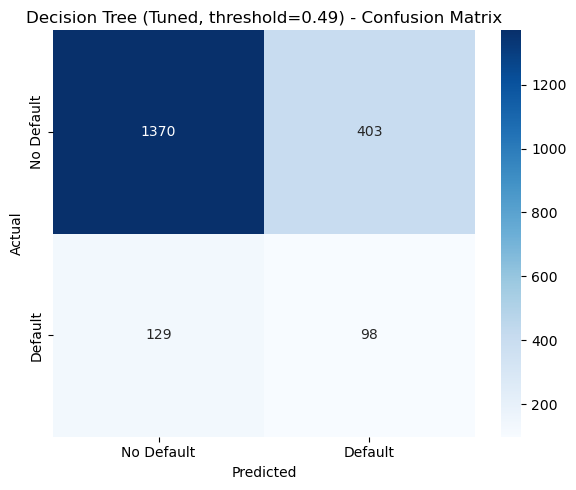

In [31]:
# Create confusion matrix
cm = plot_confusion_matrix(y_test, y_test_pred, f'Decision Tree (Tuned, threshold={best_threshold:.2f})')

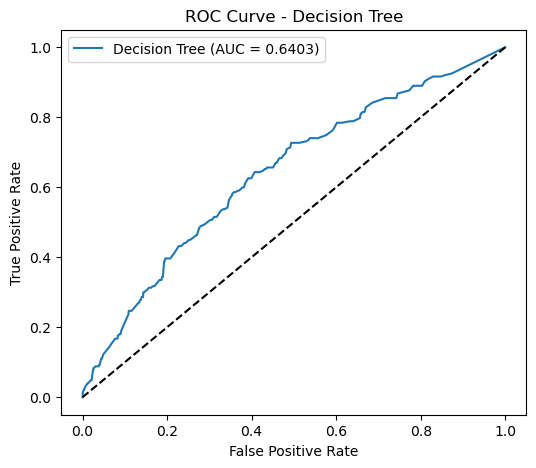

In [32]:
#Create ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {test_roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Decision Tree')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


In [33]:
#Find feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))


           Feature  Importance
0              Age    0.152323
9        Education    0.136175
5   NumCreditLines    0.121515
7         LoanTerm    0.087554
6     InterestRate    0.079538
4   MonthsEmployed    0.067143
2       LoanAmount    0.060033
12     HasCoSigner    0.049940
1           Income    0.048812
11   HasDependents    0.027934


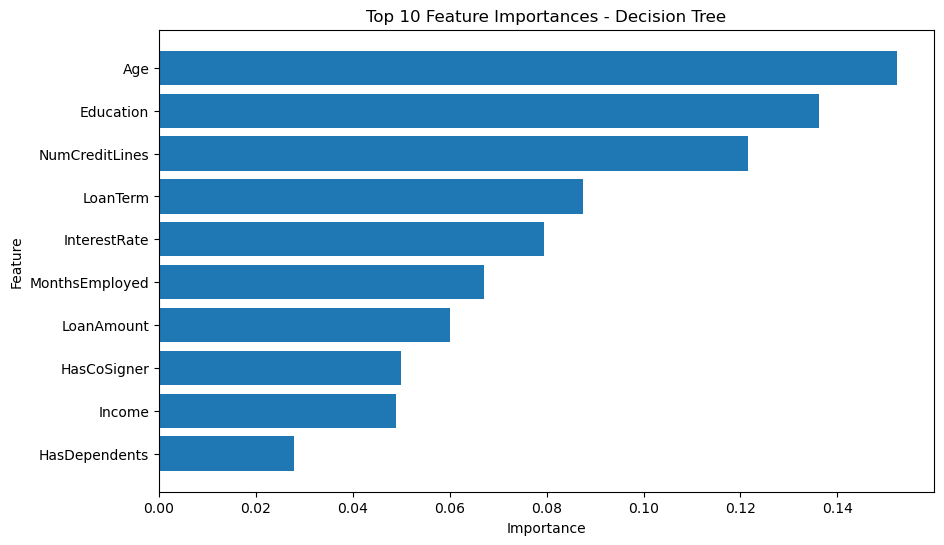

In [34]:
#Plot feature importance
top_features = importance_df.head(10).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


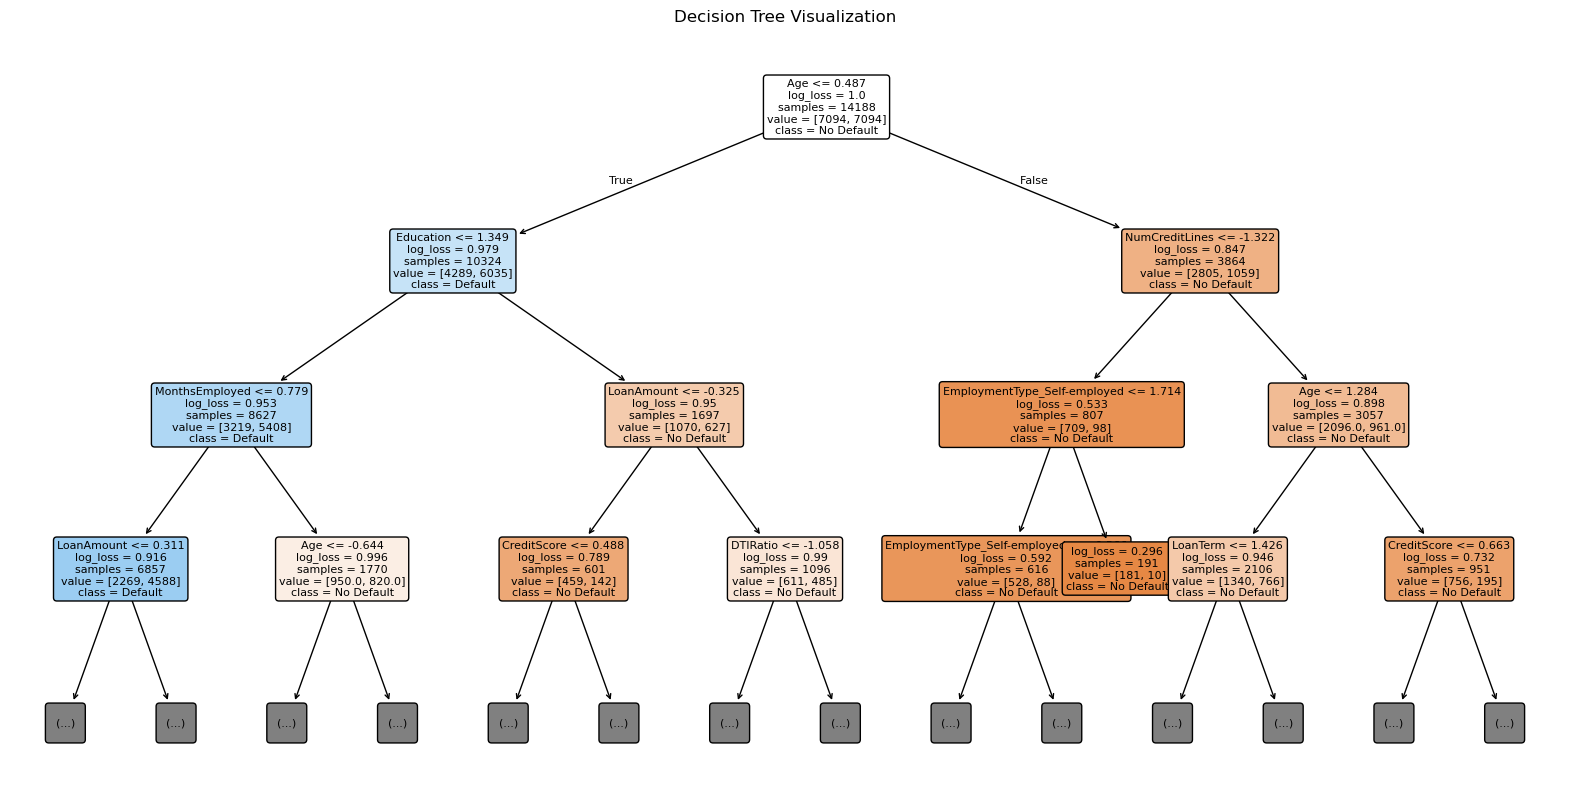

In [35]:
#Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['No Default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree Visualization")
plt.show()


In [36]:
# Save the tuned model summary in CSV file
results_summary = pd.DataFrame({
    'Model': ['Decision Tree (Tuned)'],
    'Train Accuracy': [train_accuracy],
    'Train Precision': [train_precision],
    'Train Recall': [train_recall],
    'Train F1': [train_f1],
    'Test Accuracy': [test_accuracy],
    'Test Precision': [test_precision],
    'Test Recall': [test_recall],
    'Test F1': [test_f1],
    'Test ROC-AUC': [test_roc_auc],
    'Best Threshold': [best_threshold],
    'Best Params': [str(dt_search.best_params_)]
})

results_summary.to_csv('../results/decision_tree_results.csv', index=False)

# Also save baseline vs tuned comparison for the key test metrics
comparison_summary.to_csv('../results/decision_tree_baseline_vs_tuned.csv', index=False)

print("Results saved successfully!")
results_summary

Results saved successfully!


,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Best Threshold,Best Params
0,Decision Tree (Tuned),0.835072,0.838411,0.830138,0.834254,0.734,0.195609,0.431718,0.269231,0.64026,0.49,"{'min_samples_split': 20, 'min_samples_leaf': ..."


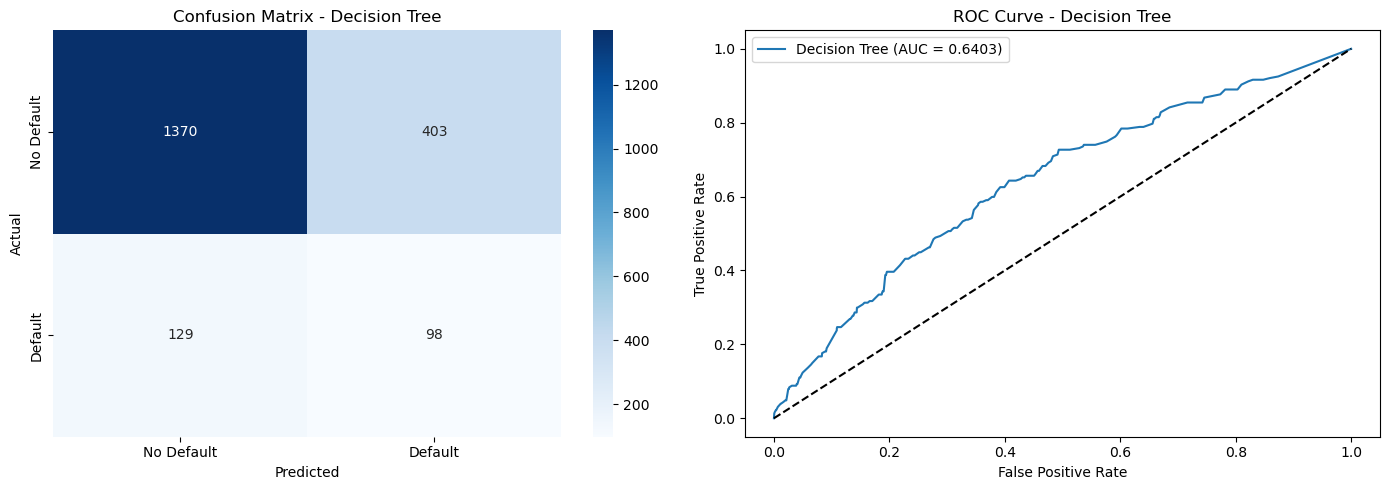

In [37]:
#Save confusion matrix and ROC curve image
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
axes[1].plot(fpr, tpr, label=f'Decision Tree (AUC = {test_roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve - Decision Tree')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/decision_tree_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()


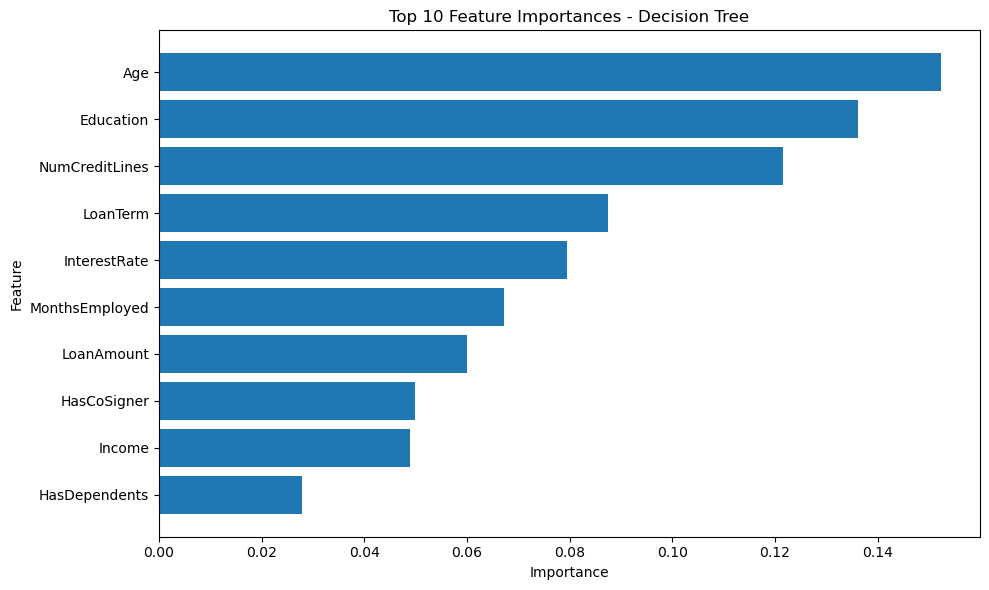

In [38]:
#Save feature importance plot
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../results/decision_tree_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


In [39]:
# Save short text summary
with open('../results/decision_tree_summary.txt', 'w') as f:
    f.write("Decision Tree Model Summary\n")
    f.write("===========================\n\n")
    f.write("Configuration:\n")
    f.write(f"Best Params: {dt_search.best_params_}\n")
    f.write(f"Best Threshold: {best_threshold:.2f}\n\n")
    f.write(f"Train Accuracy: {train_accuracy:.4f}\n")
    f.write(f"Train Precision: {train_precision:.4f}\n")
    f.write(f"Train Recall: {train_recall:.4f}\n")
    f.write(f"Train F1-score: {train_f1:.4f}\n\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
    f.write(f"Test Precision: {test_precision:.4f}\n")
    f.write(f"Test Recall: {test_recall:.4f}\n")
    f.write(f"Test F1-score: {test_f1:.4f}\n")
    f.write(f"Test ROC-AUC: {test_roc_auc:.4f}\n\n")
    f.write("Top 10 Important Features:\n")
    for _, row in importance_df.head(10).iterrows():
        f.write(f"{row['Feature']} : {row['Importance']:.4f}\n")

print("Summary file saved!")

Summary file saved!
